In [4]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [5]:
NUM_SAMPLES = 500

config_base = load_config('configs/default.yaml')

config = config_base
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["freq_save"] = 0


version : default
seed : 1
x0 : 0.5
y0 : 0.5
T : 10
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : no_reg
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5


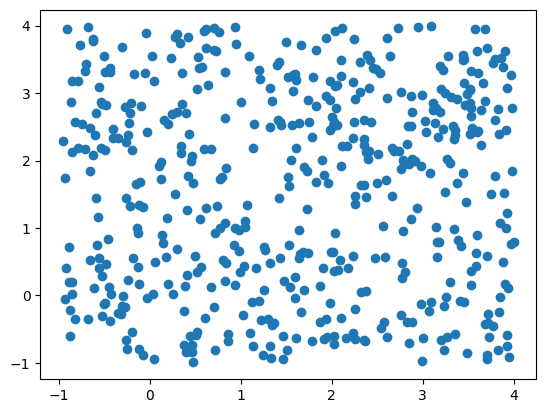

Model: "nested_PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,852 (30.67 KB)

 Trainable params: 7,852 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_95 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,852 (30.67 KB)

 Trainable params: 7,852 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***
Training started...
    0/25000 | loss: 3.61e+01
 1000/25000 | loss: 3.40e-02
 2000/25000 | loss: 6.59e-03
 3000/25000 | loss: 1.07e-03
 4000/25000 | loss: 1.16e-03
 5000/25000 | loss: 8.56e-04
 6000/25000 | loss: 5.53e-04
 7000/25000 | loss: 2.68e-03
 8000/25000 | loss: 8.80e-05
 9000/25000 | loss: 2.30e-04
10000/25000 | loss: 1.60e-05
11000/25000 | loss: 6.43e-05
12000/25000 | loss: 9.70e-05
13000/25000 | loss: 2.22e-05
14000/25000 | loss: 1.60e-04
15000/25000 | loss: 9.32e-05
16000/25000 | loss: 1.89e-05
17000/25000 | loss: 2.07e-03
18000/25000 | loss: 2.67e-06


In [ ]:
x0s = np.random.uniform(-1, 4, size=NUM_SAMPLES)
y0s = np.random.uniform(-1, 4, size=NUM_SAMPLES)


plt.scatter(x0s, y0s)
plt.show()

dirname_no_reg = f"logs/models/visualization_experiments/no_reg"
if not os.path.exists(dirname_no_reg):
    os.makedirs(dirname_no_reg)

dirname_reg_derivative = f"logs/models/visualization_experiments/reg_derivative"
if not os.path.exists(dirname_reg_derivative):
    os.makedirs(dirname_reg_derivative)

dirname_reg_derivative_unstable_fp = f"logs/models/visualization_experiments/reg_derivative_unstable_fp"
if not os.path.exists(dirname_reg_derivative_unstable_fp):
    os.makedirs(dirname_reg_derivative_unstable_fp)

results_list = []

for i in range(NUM_SAMPLES):
    config["x0"] = float(x0s[i])
    config["y0"] = float(y0s[i])
    
    try:
        # Without regularization
        config["regularizer"] = "no_reg"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_no_reg}/run_{i}.pkl")

        t_line, x_true, y_true = PINN.data.reference()

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_no_reg = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15



        # With time derivative regularization
        config["regularizer"] = "reg_derivative"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_reg_derivative}/run_{i}.pkl")

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15


        # With unstable fp regularization
        config["regularizer"] = "reg_derivative_unstable_fp"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()
        
        PINN.save_weights(f"{dirname_reg_derivative_unstable_fp}/run_{i}.pkl")
        
        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative_unstable_fp = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15

        table_entry = pd.DataFrame({"(x0, y0)": [(float(x0s[i]), float(y0s[i]))], 
                                    "success_no_reg": [loss_success_no_reg],
                                    "success_reg_derivative": [loss_success_reg_derivative],
                                    "success_reg_derivative_unstable_fp": [loss_success_reg_derivative_unstable_fp]})
        
        results_list.append(table_entry)
        results_table = pd.concat(results_list)
        results_table.to_csv("visual_results.csv")

    except Exception as e:
        print(e)
            
     